In [1]:
!pip install torchvision -q

In [2]:
import torch
import os
from torch.utils.data import  DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [3]:
# images load => transform => dataset of al images

class ImageProcessor():
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [4]:
# Check dimensio of image

from PIL import Image

img = Image.open('/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba/000001.jpg')
width, height = img.size
print(f"Width: {width}, Height: {height}")

Width: 178, Height: 218


In [5]:
root_dir_path = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [6]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"Loaded {len(dataset)} images")

Loaded 202599 images


In [7]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Generator Network

In [8]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [9]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()
        
        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),
            
            nn.Linear(256, 512),
            nn.ReLU(),
            
            nn.Linear(512, 1024),
            nn.ReLU(),
            
            nn.Linear(1024, 64 * 64 * img_channels),
            nn.Tanh() # Rescales output to [-1, 1]
        )
        
    def forward(self, z):   # z = noise
        img = self.model(z)
        # Reshape the flat vector back into an image (Batch, Channels, Height, Width)
        img = img.view(img.size(0), 3, 64, 64)
        return img

        # fake img ==> 64 x 64 x 3 x batch_size

# Discriminator Network

In [10]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()
        
        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Linear(256, 1),
            nn.Sigmoid() # probability of being real/fake
        )
        
    def forward(self, img):
        return self.model(img)

In [11]:
# Define Loss and Optimizers
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [12]:
import torch 

# Device setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cuda


In [13]:
# Move models to the selected device
generator = generator.to(device)
discriminator = discriminator.to(device)

# Training the GAN

In [14]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 200 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [15]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/20... batch: 1... G-loss:0.7218647599220276.... D-loss: 0.6965888738632202
for epoch: 1/20... batch: 201... G-loss:0.8149294853210449.... D-loss: 0.3839031159877777
for epoch: 1/20... batch: 401... G-loss:1.768815517425537.... D-loss: 0.13469432294368744
for epoch: 1/20... batch: 601... G-loss:1.8856996297836304.... D-loss: 0.20841039717197418
for epoch: 1/20... batch: 801... G-loss:3.867043972015381.... D-loss: 0.08158337324857712
for epoch: 1/20... batch: 1001... G-loss:4.290764808654785.... D-loss: 0.10991702973842621
for epoch: 1/20... batch: 1201... G-loss:3.42033052444458.... D-loss: 0.1559600532054901
for epoch: 1/20... batch: 1401... G-loss:5.397496223449707.... D-loss: 0.29421332478523254


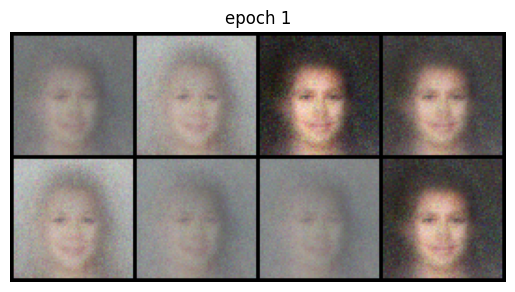

for epoch: 2/20... batch: 1... G-loss:2.593935489654541.... D-loss: 0.1710442304611206
for epoch: 2/20... batch: 201... G-loss:6.223400115966797.... D-loss: 0.18420185148715973
for epoch: 2/20... batch: 401... G-loss:4.15263557434082.... D-loss: 0.11816975474357605
for epoch: 2/20... batch: 601... G-loss:4.509828090667725.... D-loss: 0.2226288765668869
for epoch: 2/20... batch: 801... G-loss:4.248346328735352.... D-loss: 0.0769096091389656
for epoch: 2/20... batch: 1001... G-loss:3.4422924518585205.... D-loss: 0.12409324198961258
for epoch: 2/20... batch: 1201... G-loss:3.8707168102264404.... D-loss: 0.15882498025894165
for epoch: 2/20... batch: 1401... G-loss:3.510188579559326.... D-loss: 0.18709170818328857


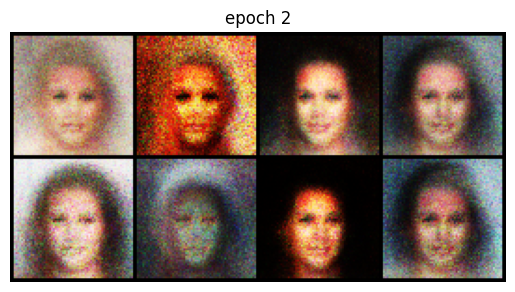

for epoch: 3/20... batch: 1... G-loss:6.435863971710205.... D-loss: 0.3998163342475891
for epoch: 3/20... batch: 201... G-loss:1.590058445930481.... D-loss: 0.36493510007858276
for epoch: 3/20... batch: 401... G-loss:1.7196476459503174.... D-loss: 0.3651408553123474
for epoch: 3/20... batch: 601... G-loss:1.9400503635406494.... D-loss: 0.3336849510669708
for epoch: 3/20... batch: 801... G-loss:2.637002468109131.... D-loss: 0.3551740050315857
for epoch: 3/20... batch: 1001... G-loss:3.2590084075927734.... D-loss: 0.37809839844703674
for epoch: 3/20... batch: 1201... G-loss:2.024447441101074.... D-loss: 0.3934999406337738
for epoch: 3/20... batch: 1401... G-loss:2.3611176013946533.... D-loss: 0.3250718116760254


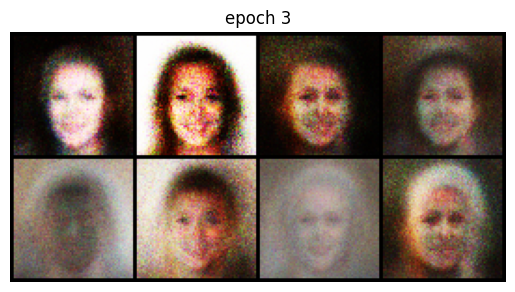

for epoch: 4/20... batch: 1... G-loss:2.3473823070526123.... D-loss: 0.41016703844070435
for epoch: 4/20... batch: 201... G-loss:1.7052979469299316.... D-loss: 0.689215898513794
for epoch: 4/20... batch: 401... G-loss:2.2249622344970703.... D-loss: 0.28880852460861206
for epoch: 4/20... batch: 601... G-loss:1.8410427570343018.... D-loss: 0.432414174079895
for epoch: 4/20... batch: 801... G-loss:1.8636723756790161.... D-loss: 0.38017404079437256
for epoch: 4/20... batch: 1001... G-loss:1.808455467224121.... D-loss: 0.4850393533706665
for epoch: 4/20... batch: 1201... G-loss:1.8035410642623901.... D-loss: 0.4861419200897217
for epoch: 4/20... batch: 1401... G-loss:1.9467486143112183.... D-loss: 0.45700711011886597


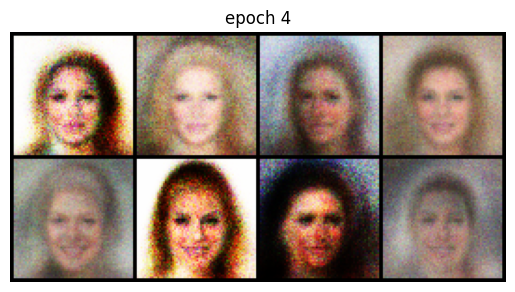

for epoch: 5/20... batch: 1... G-loss:1.9387216567993164.... D-loss: 0.40724554657936096
for epoch: 5/20... batch: 201... G-loss:1.6531435251235962.... D-loss: 0.5354452133178711
for epoch: 5/20... batch: 401... G-loss:1.6689131259918213.... D-loss: 0.45122259855270386
for epoch: 5/20... batch: 601... G-loss:2.0991134643554688.... D-loss: 0.5111477375030518
for epoch: 5/20... batch: 801... G-loss:2.189274311065674.... D-loss: 0.49529725313186646
for epoch: 5/20... batch: 1001... G-loss:1.956240177154541.... D-loss: 0.4378969669342041
for epoch: 5/20... batch: 1201... G-loss:2.0942673683166504.... D-loss: 0.4602610170841217
for epoch: 5/20... batch: 1401... G-loss:1.6469663381576538.... D-loss: 0.48790284991264343


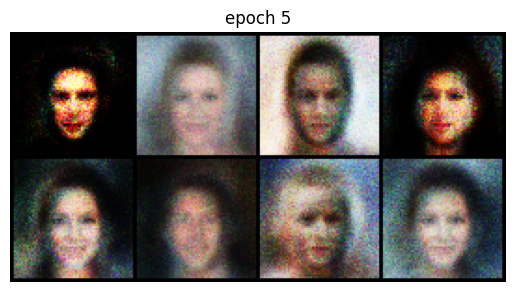

for epoch: 6/20... batch: 1... G-loss:1.9946048259735107.... D-loss: 0.40171346068382263
for epoch: 6/20... batch: 201... G-loss:1.9203708171844482.... D-loss: 0.5248202681541443
for epoch: 6/20... batch: 401... G-loss:1.7587248086929321.... D-loss: 0.47527438402175903
for epoch: 6/20... batch: 601... G-loss:2.1245057582855225.... D-loss: 0.5123650431632996
for epoch: 6/20... batch: 801... G-loss:1.85069739818573.... D-loss: 0.5594659447669983
for epoch: 6/20... batch: 1001... G-loss:2.0195822715759277.... D-loss: 0.542055070400238
for epoch: 6/20... batch: 1201... G-loss:1.4958850145339966.... D-loss: 0.4944939911365509
for epoch: 6/20... batch: 1401... G-loss:1.891542911529541.... D-loss: 0.43959566950798035


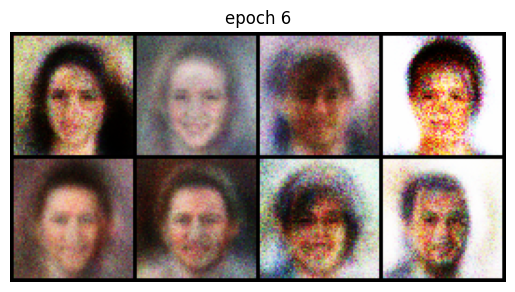

for epoch: 7/20... batch: 1... G-loss:2.013056993484497.... D-loss: 0.46733275055885315
for epoch: 7/20... batch: 201... G-loss:1.4050250053405762.... D-loss: 0.5384954214096069
for epoch: 7/20... batch: 401... G-loss:1.6746251583099365.... D-loss: 0.4420570135116577
for epoch: 7/20... batch: 601... G-loss:1.9329915046691895.... D-loss: 0.4902413487434387
for epoch: 7/20... batch: 801... G-loss:1.7873162031173706.... D-loss: 0.5275357961654663
for epoch: 7/20... batch: 1001... G-loss:1.647120475769043.... D-loss: 0.5063360333442688
for epoch: 7/20... batch: 1201... G-loss:1.798740029335022.... D-loss: 0.5146783590316772
for epoch: 7/20... batch: 1401... G-loss:2.0474963188171387.... D-loss: 0.5521663427352905


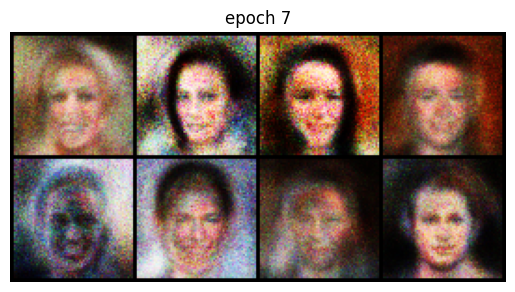

for epoch: 8/20... batch: 1... G-loss:1.798627257347107.... D-loss: 0.5780761241912842
for epoch: 8/20... batch: 201... G-loss:1.4960122108459473.... D-loss: 0.4817380905151367
for epoch: 8/20... batch: 401... G-loss:1.6957967281341553.... D-loss: 0.5048528909683228
for epoch: 8/20... batch: 601... G-loss:1.561222791671753.... D-loss: 0.5410199165344238
for epoch: 8/20... batch: 801... G-loss:1.7691196203231812.... D-loss: 0.5149244070053101
for epoch: 8/20... batch: 1001... G-loss:1.6170506477355957.... D-loss: 0.5551598072052002
for epoch: 8/20... batch: 1201... G-loss:1.4020123481750488.... D-loss: 0.5390604138374329
for epoch: 8/20... batch: 1401... G-loss:1.5338228940963745.... D-loss: 0.6081382036209106


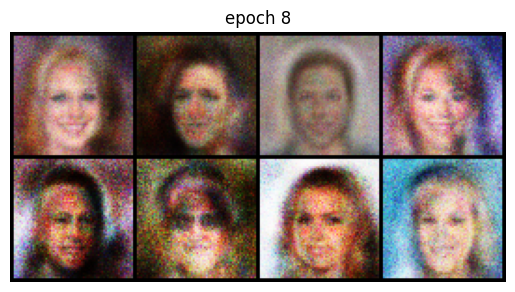

for epoch: 9/20... batch: 1... G-loss:1.6647145748138428.... D-loss: 0.5386784076690674
for epoch: 9/20... batch: 201... G-loss:1.3989923000335693.... D-loss: 0.5441704988479614
for epoch: 9/20... batch: 401... G-loss:1.6067049503326416.... D-loss: 0.48048436641693115
for epoch: 9/20... batch: 601... G-loss:1.5227553844451904.... D-loss: 0.5375272035598755
for epoch: 9/20... batch: 801... G-loss:1.693397045135498.... D-loss: 0.5165117979049683
for epoch: 9/20... batch: 1001... G-loss:1.488992691040039.... D-loss: 0.4849717617034912
for epoch: 9/20... batch: 1201... G-loss:1.5616662502288818.... D-loss: 0.5336613059043884
for epoch: 9/20... batch: 1401... G-loss:1.5572247505187988.... D-loss: 0.5536470413208008


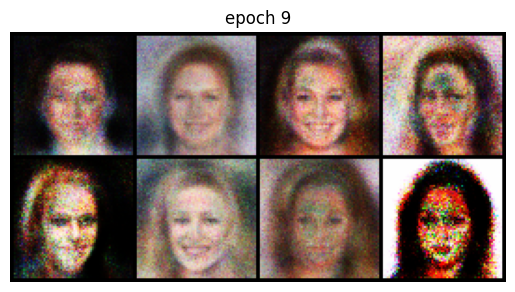

for epoch: 10/20... batch: 1... G-loss:1.4408961534500122.... D-loss: 0.533432126045227
for epoch: 10/20... batch: 201... G-loss:1.6585760116577148.... D-loss: 0.522922933101654
for epoch: 10/20... batch: 401... G-loss:1.4398560523986816.... D-loss: 0.49613696336746216
for epoch: 10/20... batch: 601... G-loss:1.32616126537323.... D-loss: 0.5729820132255554
for epoch: 10/20... batch: 801... G-loss:1.433475136756897.... D-loss: 0.5713503360748291
for epoch: 10/20... batch: 1001... G-loss:1.5361297130584717.... D-loss: 0.5100346207618713
for epoch: 10/20... batch: 1201... G-loss:1.4133449792861938.... D-loss: 0.4982164800167084
for epoch: 10/20... batch: 1401... G-loss:1.6038730144500732.... D-loss: 0.5628902912139893


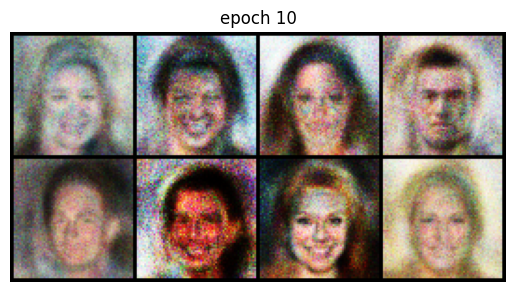

for epoch: 11/20... batch: 1... G-loss:1.6958645582199097.... D-loss: 0.5115216970443726
for epoch: 11/20... batch: 201... G-loss:1.4513421058654785.... D-loss: 0.5583853721618652
for epoch: 11/20... batch: 401... G-loss:1.2844475507736206.... D-loss: 0.5501246452331543
for epoch: 11/20... batch: 601... G-loss:1.3314297199249268.... D-loss: 0.5448172688484192
for epoch: 11/20... batch: 801... G-loss:1.4039363861083984.... D-loss: 0.5838770866394043
for epoch: 11/20... batch: 1001... G-loss:1.3813972473144531.... D-loss: 0.5390928983688354
for epoch: 11/20... batch: 1201... G-loss:1.2939201593399048.... D-loss: 0.5701475739479065
for epoch: 11/20... batch: 1401... G-loss:1.3598315715789795.... D-loss: 0.5604389309883118


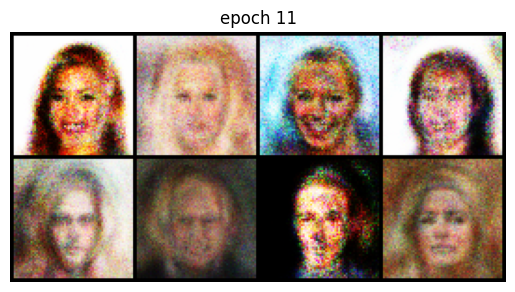

for epoch: 12/20... batch: 1... G-loss:1.2989683151245117.... D-loss: 0.5779038071632385
for epoch: 12/20... batch: 201... G-loss:1.430295467376709.... D-loss: 0.6621761918067932
for epoch: 12/20... batch: 401... G-loss:1.222854733467102.... D-loss: 0.5784550905227661
for epoch: 12/20... batch: 601... G-loss:1.3495336771011353.... D-loss: 0.5786762833595276
for epoch: 12/20... batch: 801... G-loss:1.5064334869384766.... D-loss: 0.6020024418830872
for epoch: 12/20... batch: 1001... G-loss:1.4222362041473389.... D-loss: 0.5501012206077576
for epoch: 12/20... batch: 1201... G-loss:1.3044407367706299.... D-loss: 0.5483626127243042
for epoch: 12/20... batch: 1401... G-loss:1.342492938041687.... D-loss: 0.5196186900138855


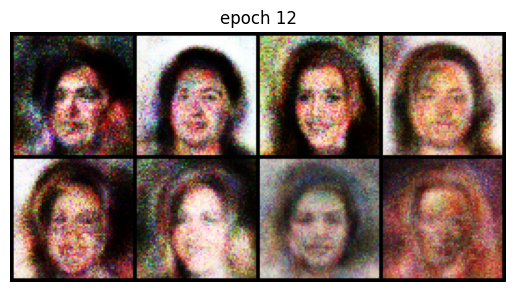

for epoch: 13/20... batch: 1... G-loss:1.179714322090149.... D-loss: 0.5986671447753906
for epoch: 13/20... batch: 201... G-loss:1.3260914087295532.... D-loss: 0.5457724332809448
for epoch: 13/20... batch: 401... G-loss:1.2079670429229736.... D-loss: 0.5763781070709229
for epoch: 13/20... batch: 601... G-loss:1.3165230751037598.... D-loss: 0.5298323035240173
for epoch: 13/20... batch: 801... G-loss:1.2488031387329102.... D-loss: 0.5323330760002136
for epoch: 13/20... batch: 1001... G-loss:1.333970069885254.... D-loss: 0.5810861587524414
for epoch: 13/20... batch: 1201... G-loss:1.2414833307266235.... D-loss: 0.623013973236084
for epoch: 13/20... batch: 1401... G-loss:1.2747371196746826.... D-loss: 0.5543298721313477


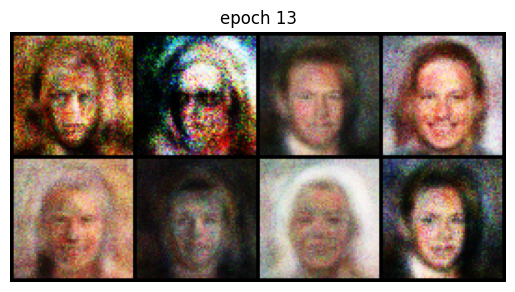

for epoch: 14/20... batch: 1... G-loss:1.363114356994629.... D-loss: 0.5305970907211304
for epoch: 14/20... batch: 201... G-loss:1.376983404159546.... D-loss: 0.5425724983215332
for epoch: 14/20... batch: 401... G-loss:1.2476228475570679.... D-loss: 0.5782425403594971
for epoch: 14/20... batch: 601... G-loss:1.4032175540924072.... D-loss: 0.5273717641830444
for epoch: 14/20... batch: 801... G-loss:1.3332774639129639.... D-loss: 0.7337524890899658
for epoch: 14/20... batch: 1001... G-loss:1.4313921928405762.... D-loss: 0.5900406241416931
for epoch: 14/20... batch: 1201... G-loss:1.2977524995803833.... D-loss: 0.5412803888320923
for epoch: 14/20... batch: 1401... G-loss:1.286229133605957.... D-loss: 0.5974198579788208


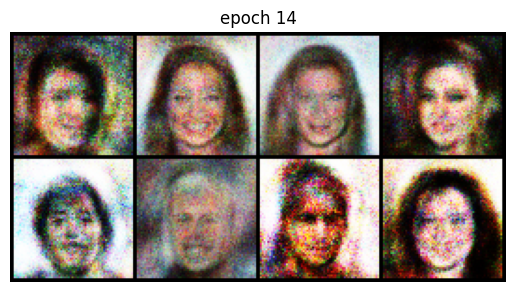

for epoch: 15/20... batch: 1... G-loss:1.4283361434936523.... D-loss: 0.5058659315109253
for epoch: 15/20... batch: 201... G-loss:1.2733854055404663.... D-loss: 0.5990402698516846
for epoch: 15/20... batch: 401... G-loss:1.3159310817718506.... D-loss: 0.5011682510375977
for epoch: 15/20... batch: 601... G-loss:1.375495433807373.... D-loss: 0.5783754587173462
for epoch: 15/20... batch: 801... G-loss:1.2153211832046509.... D-loss: 0.568641185760498
for epoch: 15/20... batch: 1001... G-loss:1.1648664474487305.... D-loss: 0.5268772840499878
for epoch: 15/20... batch: 1201... G-loss:1.270334005355835.... D-loss: 0.5475836992263794
for epoch: 15/20... batch: 1401... G-loss:1.2329838275909424.... D-loss: 0.5531680583953857


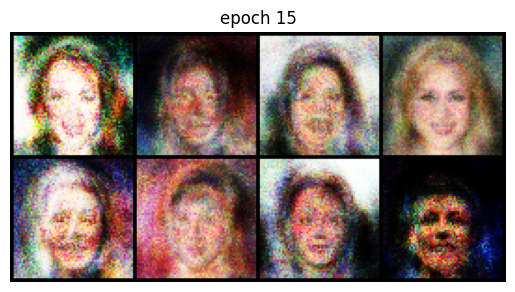

for epoch: 16/20... batch: 1... G-loss:1.3975353240966797.... D-loss: 0.5258877873420715
for epoch: 16/20... batch: 201... G-loss:1.3176767826080322.... D-loss: 0.5653090476989746
for epoch: 16/20... batch: 401... G-loss:1.1751176118850708.... D-loss: 0.5459591150283813
for epoch: 16/20... batch: 601... G-loss:1.2684221267700195.... D-loss: 0.5972689390182495
for epoch: 16/20... batch: 801... G-loss:1.2140185832977295.... D-loss: 0.5828466415405273
for epoch: 16/20... batch: 1001... G-loss:1.2603764533996582.... D-loss: 0.555243730545044
for epoch: 16/20... batch: 1201... G-loss:1.3904670476913452.... D-loss: 0.5853167772293091
for epoch: 16/20... batch: 1401... G-loss:1.3801372051239014.... D-loss: 0.5632991790771484


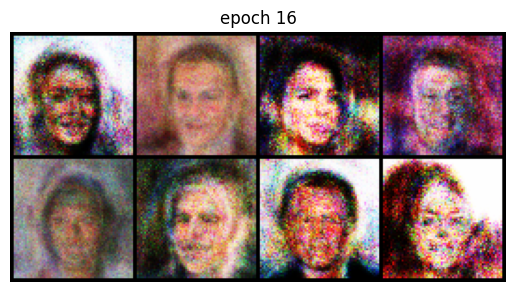

for epoch: 17/20... batch: 1... G-loss:1.255692481994629.... D-loss: 0.5650637149810791
for epoch: 17/20... batch: 201... G-loss:1.2289789915084839.... D-loss: 0.5899283289909363
for epoch: 17/20... batch: 401... G-loss:1.3284122943878174.... D-loss: 0.5566818118095398
for epoch: 17/20... batch: 601... G-loss:1.3115547895431519.... D-loss: 0.5487228631973267
for epoch: 17/20... batch: 801... G-loss:1.3803819417953491.... D-loss: 0.5346028208732605
for epoch: 17/20... batch: 1001... G-loss:1.3849724531173706.... D-loss: 0.5841848254203796
for epoch: 17/20... batch: 1201... G-loss:1.3661110401153564.... D-loss: 0.5969619750976562
for epoch: 17/20... batch: 1401... G-loss:1.3491592407226562.... D-loss: 0.5583033561706543


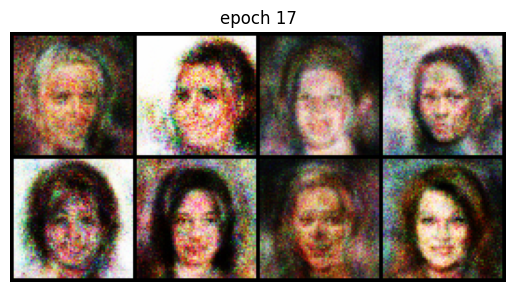

for epoch: 18/20... batch: 1... G-loss:1.458464503288269.... D-loss: 0.5539790391921997
for epoch: 18/20... batch: 201... G-loss:1.374955177307129.... D-loss: 0.5551337599754333
for epoch: 18/20... batch: 401... G-loss:1.263319730758667.... D-loss: 0.6054501533508301
for epoch: 18/20... batch: 601... G-loss:1.4523483514785767.... D-loss: 0.5318987965583801
for epoch: 18/20... batch: 801... G-loss:1.3064439296722412.... D-loss: 0.6086710095405579
for epoch: 18/20... batch: 1001... G-loss:1.3977763652801514.... D-loss: 0.5691663026809692
for epoch: 18/20... batch: 1201... G-loss:1.4234806299209595.... D-loss: 0.5332832336425781
for epoch: 18/20... batch: 1401... G-loss:1.5184729099273682.... D-loss: 0.5183240175247192


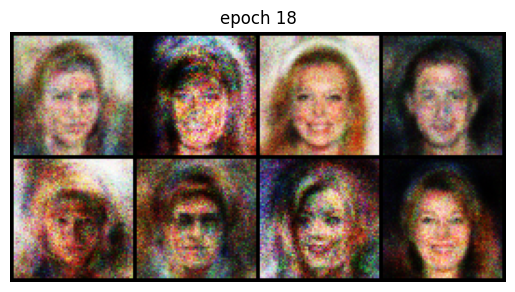

for epoch: 19/20... batch: 1... G-loss:1.237199068069458.... D-loss: 0.5239881277084351
for epoch: 19/20... batch: 201... G-loss:1.2833573818206787.... D-loss: 0.5230029821395874
for epoch: 19/20... batch: 401... G-loss:1.345562219619751.... D-loss: 0.5632771253585815
for epoch: 19/20... batch: 601... G-loss:1.3849353790283203.... D-loss: 0.5978215932846069
for epoch: 19/20... batch: 801... G-loss:1.427321195602417.... D-loss: 0.5755296349525452
for epoch: 19/20... batch: 1001... G-loss:1.3873523473739624.... D-loss: 0.5390628576278687
for epoch: 19/20... batch: 1201... G-loss:1.2640118598937988.... D-loss: 0.6094974279403687
for epoch: 19/20... batch: 1401... G-loss:1.307515263557434.... D-loss: 0.5491079092025757


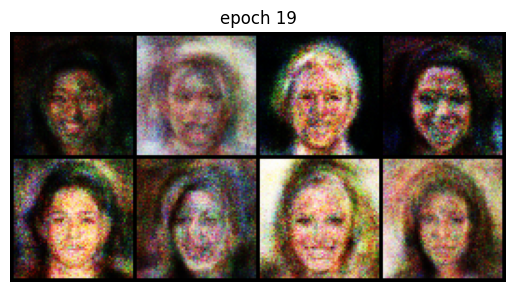

for epoch: 20/20... batch: 1... G-loss:1.2900912761688232.... D-loss: 0.524053692817688
for epoch: 20/20... batch: 201... G-loss:1.3383450508117676.... D-loss: 0.5864492654800415
for epoch: 20/20... batch: 401... G-loss:1.2879365682601929.... D-loss: 0.591140627861023
for epoch: 20/20... batch: 601... G-loss:1.3719007968902588.... D-loss: 0.6023327112197876
for epoch: 20/20... batch: 801... G-loss:1.2343170642852783.... D-loss: 0.5936741828918457
for epoch: 20/20... batch: 1001... G-loss:1.2408440113067627.... D-loss: 0.5845421552658081
for epoch: 20/20... batch: 1201... G-loss:1.2718334197998047.... D-loss: 0.5761740207672119
for epoch: 20/20... batch: 1401... G-loss:1.581970453262329.... D-loss: 0.6045089960098267


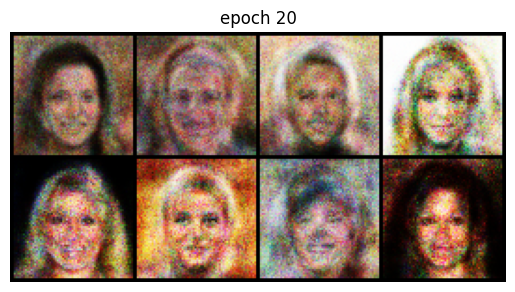

In [16]:
train(generator, discriminator, dataloader, epochs=20)